In [20]:
import importlib
import torch
import pandas as pd
import numpy as np
import model_code.hidden_state_analysis as analysis
# import model_code.steering_extraction as steering_extraction
# from model_code.steering_extraction import  generateSteering, retrieve_steering_vector

importlib.reload(analysis)
# importlib.reload(steering_extraction)

<module 'model_code.hidden_state_analysis' from '/workspace/Dissertation_Project/model_code/hidden_state_analysis.py'>

In [2]:

# steering_vector_eng = torch.load("resources/saved_vectors/English Vectors LLAMA ID/steering_vectors.pt")
# steering_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors LLAMA ID/steering_vectors.pt")

# steering_vector_eng_LLAMA_eng = torch.load("resources/saved_vectors/English Vectors/steering_vectors.pt")
# steering_vector_id_LLAMA_eng = torch.load("resources/saved_vectors/Indonesian Vectors/steering_vectors.pt")


# LLAMA original 
Llama_eng_emotion_vector_eng = torch.load("resources/saved_vectors/English Vectors/emotion_vectors.pt" , weights_only = False)
Llama_eng_emotion_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors/emotion_vectors.pt", weights_only = False)

Llama_eng_steering_vector_eng = torch.load("resources/saved_vectors/English Vectors/steering_vectors.pt")
Llama_eng_steering_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors/steering_vectors.pt")

# LLAMA Indonesian 
Llama_indo_emotion_vector_eng = torch.load("resources/saved_vectors/English Vectors LLAMA ID/emotion_vectors.pt", weights_only = False)
Llama_indo_emotion_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors LLAMA ID/emotion_vectors.pt", weights_only = False)

Llama_indo_steering_vector_eng = torch.load("resources/saved_vectors/English Vectors LLAMA ID/steering_vectors.pt")
Llama_indo_steering_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors LLAMA ID/steering_vectors.pt")


# Probing across different emotion across languages

## Data Modification 

In [17]:
all_emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']

# x = np.stack(Llama_indo_emotion_vector_eng['anger'], axis=0)

# x.shape
mdfLLAMAD_ID_eng ={
    emo: np.stack(Llama_indo_emotion_vector_eng[emo], axis=0)
    for emo in all_emotions
}
mdfLLAMAD_ID_id = {
    emo: np.stack(Llama_indo_emotion_vector_id[emo], axis=0)
    for emo in all_emotions
}


## Binary Probe 

In [21]:



total_layers = 32

probe_eng = {}
probe_id = {}
result_stored = {}

# English to English probe perfomance 
english_english_probe_performance = {}
# English to Indonesian probe perfomance
english_indonesian_probe_performance = {}
# Indonesian to Indonesian probe perfomance
indonesian_indonesian_probe_performance = {}
# Indonesian to English probe perfomance
indonesian_english_probe_performance = {}



for layer in range(total_layers):
    # Transform data to the correct shape for the probe
    eng_layer_dict = {
        emo: torch.from_numpy(mdfLLAMAD_ID_eng[emo][:, layer, :])
        for emo in all_emotions
    }
    id_layer_dict = {
        emo: torch.from_numpy(mdfLLAMAD_ID_id[emo][:, layer, :])
        for emo in all_emotions
    }

    for emotion in all_emotions:
        # 4096 input => 1 output, binary classification
        probe_eng_model = analysis.LogisticRegressionProbe(
            input_dim=eng_layer_dict[emotion].shape[-1],
            output_dim=1,
        )
        probe_id_model = analysis.LogisticRegressionProbe(
            input_dim=id_layer_dict[emotion].shape[-1],
            output_dim=1,
        )
        # Dataloader
        emotion_data_eng_train, emotion_data_eng_val = analysis.create_dataloader(
            eng_layer_dict, emotion=emotion, val_ratio=0.4
        )

        emotion_data_id_train, emotion_data_id_val = analysis.create_dataloader(
            id_layer_dict, emotion=emotion, val_ratio=0.4
        )

        # Training the probe based on Indonesian english dataset and storing probe
        if layer not in probe_eng:
            probe_eng[layer] = {}
        probe_eng[layer][emotion] = analysis.trainProbe(probe_eng_model, emotion_data_eng_train, emotion_data_eng_val)
        # Training the probe based on Indonesian dataset and storing probe
        if layer not in probe_id:
            probe_id[layer] = {}
        probe_id[layer][emotion] = analysis.trainProbe(probe_id_model, emotion_data_id_train, emotion_data_id_val)

        # Probing perfomances 
        if layer not in english_english_probe_performance:
            english_english_probe_performance[layer] = {}
        if layer not in english_indonesian_probe_performance:
            english_indonesian_probe_performance[layer] = {}
        if layer not in indonesian_indonesian_probe_performance:
            indonesian_indonesian_probe_performance[layer] = {}
        if layer not in indonesian_english_probe_performance:
            indonesian_english_probe_performance[layer] = {}

        english_english_probe_performance[layer][emotion] = analysis.predictProbe(probe_eng[layer][emotion], emotion_data_eng_val)
        english_indonesian_probe_performance[layer][emotion] = analysis.predictProbe(probe_eng[layer][emotion], emotion_data_id_val)
        indonesian_indonesian_probe_performance[layer][emotion] = analysis.predictProbe(probe_id[layer][emotion], emotion_data_id_val)
        indonesian_english_probe_performance[layer][emotion] = analysis.predictProbe(probe_id[layer][emotion], emotion_data_eng_val)

    

Epoch 1/10, Loss: 0.6934
Validation Accuracy: 0.4875
Epoch 2/10, Loss: 0.6913
Validation Accuracy: 0.5250
Epoch 3/10, Loss: 0.6898
Validation Accuracy: 0.5906
Epoch 4/10, Loss: 0.6885
Validation Accuracy: 0.5250
Epoch 5/10, Loss: 0.6872
Validation Accuracy: 0.5344
Epoch 6/10, Loss: 0.6859
Validation Accuracy: 0.5969
Epoch 7/10, Loss: 0.6845
Validation Accuracy: 0.6250
Epoch 8/10, Loss: 0.6833
Validation Accuracy: 0.6219
Epoch 9/10, Loss: 0.6821
Validation Accuracy: 0.6188
Epoch 10/10, Loss: 0.6808
Validation Accuracy: 0.6188
Epoch 1/10, Loss: 0.6931
Validation Accuracy: 0.4875
Epoch 2/10, Loss: 0.6911
Validation Accuracy: 0.6406
Epoch 3/10, Loss: 0.6888
Validation Accuracy: 0.6406
Epoch 4/10, Loss: 0.6871
Validation Accuracy: 0.6312
Epoch 5/10, Loss: 0.6854
Validation Accuracy: 0.6312
Epoch 6/10, Loss: 0.6835
Validation Accuracy: 0.6250
Epoch 7/10, Loss: 0.6818
Validation Accuracy: 0.6500
Epoch 8/10, Loss: 0.6799
Validation Accuracy: 0.6500
Epoch 9/10, Loss: 0.6785
Validation Accuracy:

In [23]:
# Print probe results from the layer-wise run above
summary_rows = []

for layer in range(total_layers):
    for emotion in all_emotions:
        summary_rows.append({
            "layer": layer,
            "emotion": emotion,
            "EN->EN": float(np.mean(english_english_probe_performance[layer][emotion])),
            "EN->ID": float(np.mean(english_indonesian_probe_performance[layer][emotion])),
            "ID->ID": float(np.mean(indonesian_indonesian_probe_performance[layer][emotion])),
            "ID->EN": float(np.mean(indonesian_english_probe_performance[layer][emotion])),
        })

probe_results_df = pd.DataFrame(summary_rows)
display(probe_results_df.head(20))

print("\nAverage across emotions by layer:")
layer_avg_df = probe_results_df.groupby("layer")[["EN->EN", "EN->ID", "ID->ID", "ID->EN"]].mean().reset_index()
display(layer_avg_df)

print("\nBest layer per direction:")
for col in ["EN->EN", "EN->ID", "ID->ID", "ID->EN"]:
    best_idx = layer_avg_df[col].idxmax()
    print(f"{col}: layer {int(layer_avg_df.loc[best_idx, 'layer'])}, mean acc {layer_avg_df.loc[best_idx, col]:.4f}")

,layer,emotion,EN->EN,EN->ID,ID->ID,ID->EN
0,0,anger,0.618750,0.550000,0.634375,0.512500
1,0,happiness,0.603125,0.506250,0.634375,0.518750
2,0,sadness,0.546875,0.496875,0.846875,0.487500
3,0,love,0.790625,0.490625,0.753125,0.487500
4,0,fear,0.718750,0.490625,0.684375,0.471875
5,1,anger,0.490625,0.487500,0.568750,0.521875
6,1,happiness,0.490625,0.487500,0.593750,0.512500
7,1,sadness,0.581250,0.512500,0.590625,0.487500
8,1,love,0.700000,0.362500,0.681250,0.487500
9,1,fear,0.618750,0.578125,0.603125,0.500000



Average across emotions by layer:


,layer,EN->EN,EN->ID,ID->ID,ID->EN
0,0,0.655625,0.506875,0.710625,0.495625
1,1,0.576250,0.485625,0.607500,0.501875
2,2,0.668750,0.523125,0.635625,0.510625
3,3,0.763750,0.660000,0.700625,0.544375
4,4,0.771875,0.721250,0.796875,0.620625
5,5,0.790000,0.787500,0.840000,0.644375
6,6,0.793750,0.804375,0.875000,0.664375
7,7,0.795625,0.833750,0.890000,0.675625
8,8,0.785000,0.818125,0.880625,0.682500
9,9,0.782500,0.822500,0.885625,0.679375



Best layer per direction:
EN->EN: layer 23, mean acc 0.7981
EN->ID: layer 16, mean acc 0.8375
ID->ID: layer 31, mean acc 0.9213
ID->EN: layer 17, mean acc 0.7087


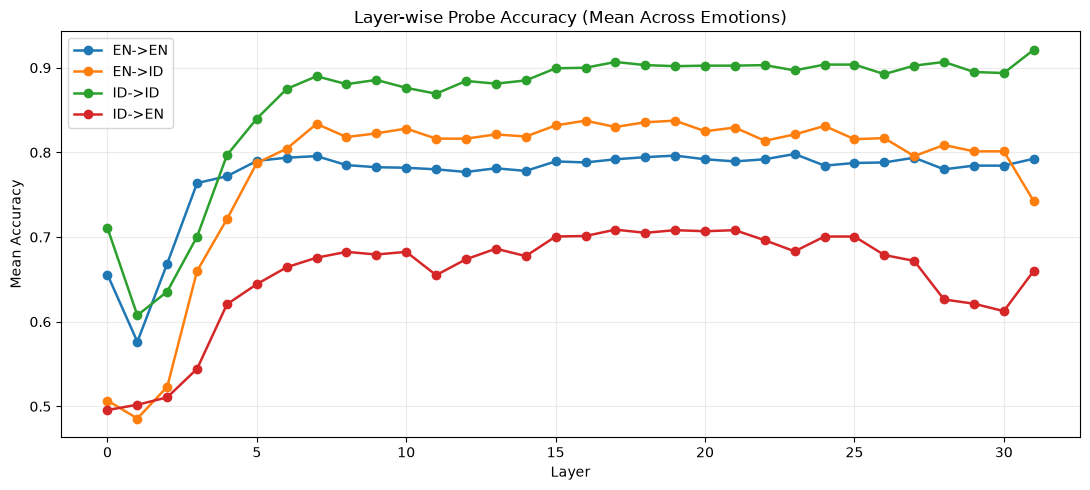

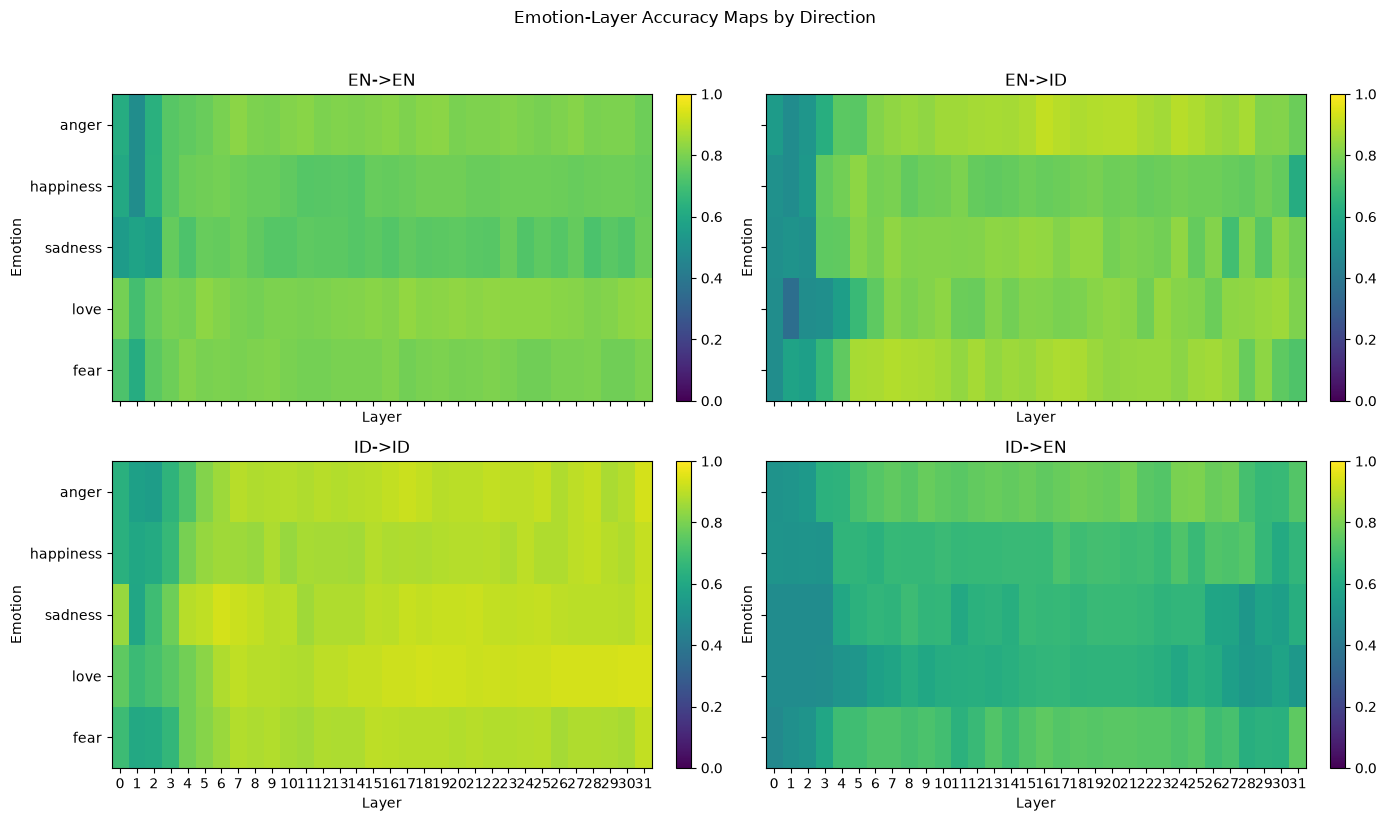

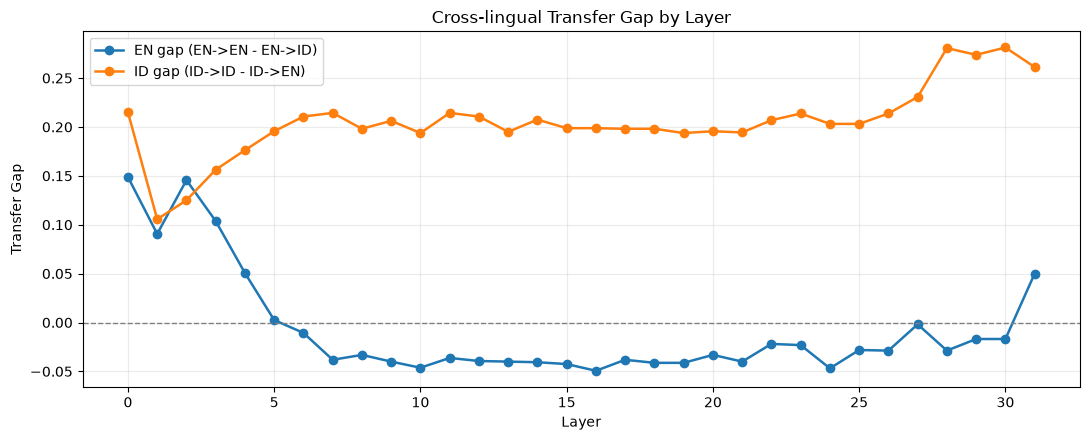

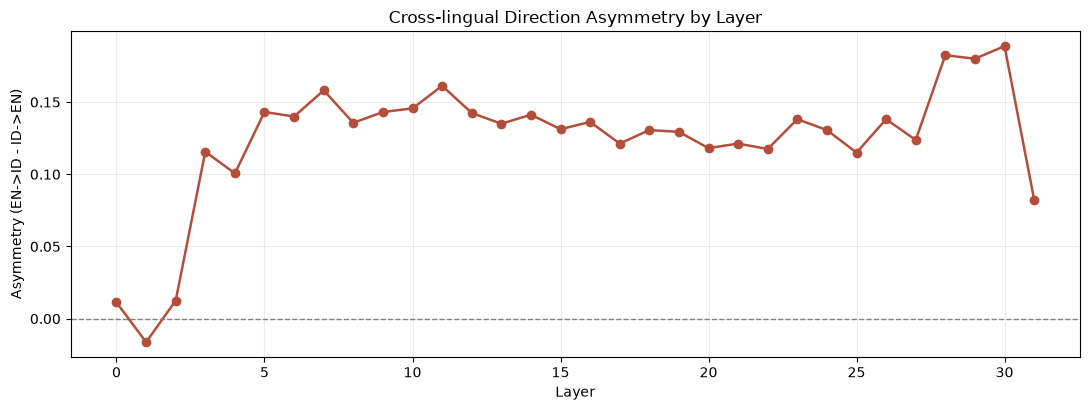

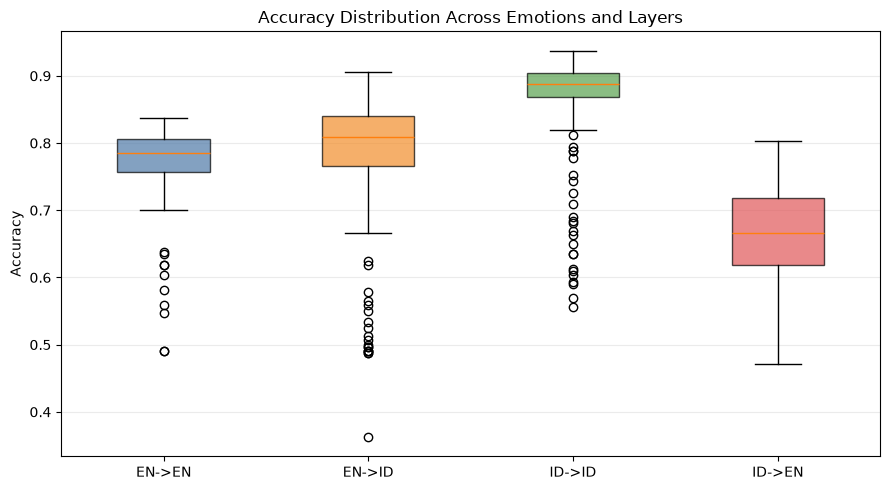

In [25]:
import matplotlib.pyplot as plt
import numpy as np

if "probe_results_df" not in globals():
    raise ValueError("Run the probe summary cell first to create probe_results_df.")

metric_cols = ["EN->EN", "EN->ID", "ID->ID", "ID->EN"]

# 1) Layer-wise overview (mean across emotions)
layer_avg_df = (
    probe_results_df.groupby("layer")[metric_cols]
    .mean()
    .reset_index()
)

plt.figure(figsize=(11, 5))
for col in metric_cols:
    plt.plot(layer_avg_df["layer"], layer_avg_df[col], marker="o", linewidth=1.8, label=col)
plt.xlabel("Layer")
plt.ylabel("Mean Accuracy")
plt.title("Layer-wise Probe Accuracy (Mean Across Emotions)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Emotion x Layer heatmaps for each direction
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
for ax, col in zip(axes.ravel(), metric_cols):
    pivot = (
        probe_results_df
        .pivot(index="emotion", columns="layer", values=col)
        .reindex(all_emotions)
    )
    im = ax.imshow(pivot.values, aspect="auto", cmap="viridis", vmin=0.0, vmax=1.0)
    ax.set_title(col)
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Emotion")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Emotion-Layer Accuracy Maps by Direction", y=1.02)
plt.tight_layout()
plt.show()

# 3) Transfer gap by layer
layer_avg_df["EN_gap"] = layer_avg_df["EN->EN"] - layer_avg_df["EN->ID"]
layer_avg_df["ID_gap"] = layer_avg_df["ID->ID"] - layer_avg_df["ID->EN"]

plt.figure(figsize=(11, 4.5))
plt.plot(layer_avg_df["layer"], layer_avg_df["EN_gap"], marker="o", linewidth=1.8, label="EN gap (EN->EN - EN->ID)")
plt.plot(layer_avg_df["layer"], layer_avg_df["ID_gap"], marker="o", linewidth=1.8, label="ID gap (ID->ID - ID->EN)")
plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Layer")
plt.ylabel("Transfer Gap")
plt.title("Cross-lingual Transfer Gap by Layer")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# 4) Directional asymmetry by layer
layer_avg_df["asymmetry"] = layer_avg_df["EN->ID"] - layer_avg_df["ID->EN"]

plt.figure(figsize=(11, 4.2))
plt.plot(layer_avg_df["layer"], layer_avg_df["asymmetry"], marker="o", linewidth=1.8, color="#B44E3A")
plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Layer")
plt.ylabel("Asymmetry (EN->ID - ID->EN)")
plt.title("Cross-lingual Direction Asymmetry by Layer")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 5) Distribution across emotions per direction
plot_data = [probe_results_df[col].values for col in metric_cols]

plt.figure(figsize=(9, 5))
box = plt.boxplot(plot_data, tick_labels=metric_cols, patch_artist=True)
colors = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759"]
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
plt.ylabel("Accuracy")
plt.title("Accuracy Distribution Across Emotions and Layers")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Multi-Class Probe 

In [30]:
all_emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']

result_stored = {}
result_stored['multiclass'] = {}
multiclass_rows = []

for layer in range(total_layers):
    emotion_vector_eng = {
        emo: mdfLLAMAD_ID_eng[emo][:, layer, :]
        for emo in all_emotions
    }
    emotion_vector_id = {
        emo: mdfLLAMAD_ID_id[emo][:, layer, :]
        for emo in all_emotions
    }

    # Build multiclass datasets using the same class order on both languages
    emotion_data_eng_train, emotion_data_eng_val = analysis.create_dataloader(
        emotion_vector_eng,
        emotion=all_emotions[0],
        val_ratio=0.4,
        multiclass=True,
        multiclass_emotions=all_emotions,
    )
    emotion_data_id_train, emotion_data_id_val = analysis.create_dataloader(
        emotion_vector_id,
        emotion=all_emotions[0],
        val_ratio=0.4,
        multiclass=True,
        multiclass_emotions=all_emotions,
    )

    # EN-trained probe
    probe_en = analysis.LogisticRegressionProbe(
        input_dim=emotion_vector_eng[all_emotions[0]].shape[-1],
        output_dim=len(all_emotions),
    )
    probe_en = analysis.trainMultiClassProbe(probe_en, emotion_data_eng_train, emotion_data_eng_val, num_epochs=25)

    # ID-trained probe
    probe_id = analysis.LogisticRegressionProbe(
        input_dim=emotion_vector_id[all_emotions[0]].shape[-1],
        output_dim=len(all_emotions),
    )
    probe_id = analysis.trainMultiClassProbe(probe_id, emotion_data_id_train, emotion_data_id_val, num_epochs=25)

    layer_scores = {
        'EN->EN': analysis.predictProbe(probe_en, emotion_data_eng_val, multiclass=True),
        'EN->ID': analysis.predictProbe(probe_en, emotion_data_id_val, multiclass=True),
        'ID->ID': analysis.predictProbe(probe_id, emotion_data_id_val, multiclass=True),
        'ID->EN': analysis.predictProbe(probe_id, emotion_data_eng_val, multiclass=True),
    }
    result_stored['multiclass'][layer] = layer_scores

    multiclass_rows.append({
        'layer': layer,
        'EN->EN': float(layer_scores['EN->EN'].mean()),
        'EN->ID': float(layer_scores['EN->ID'].mean()),
        'ID->ID': float(layer_scores['ID->ID'].mean()),
        'ID->EN': float(layer_scores['ID->EN'].mean()),
    })

# Keep probe alias for downstream confusion-matrix cell compatibility
probe = probe_id

multiclass_results_df = pd.DataFrame(multiclass_rows)
display(multiclass_results_df.head())
print(f"Trained multiclass probes for {len(multiclass_results_df)} layers")

Epoch 1/25, Loss: 1.6073
Validation Accuracy: 0.2812
Epoch 2/25, Loss: 1.5977
Validation Accuracy: 0.2812
Epoch 3/25, Loss: 1.5890
Validation Accuracy: 0.3600
Epoch 4/25, Loss: 1.5820
Validation Accuracy: 0.3150
Epoch 5/25, Loss: 1.5736
Validation Accuracy: 0.4175
Epoch 6/25, Loss: 1.5663
Validation Accuracy: 0.4675
Epoch 7/25, Loss: 1.5579
Validation Accuracy: 0.4612
Epoch 8/25, Loss: 1.5505
Validation Accuracy: 0.4487
Epoch 9/25, Loss: 1.5430
Validation Accuracy: 0.4738
Epoch 10/25, Loss: 1.5359
Validation Accuracy: 0.4738
Epoch 11/25, Loss: 1.5280
Validation Accuracy: 0.5088
Epoch 12/25, Loss: 1.5208
Validation Accuracy: 0.4950
Epoch 13/25, Loss: 1.5143
Validation Accuracy: 0.4825
Epoch 14/25, Loss: 1.5081
Validation Accuracy: 0.5238
Epoch 15/25, Loss: 1.5004
Validation Accuracy: 0.5238
Epoch 16/25, Loss: 1.4946
Validation Accuracy: 0.5325
Epoch 17/25, Loss: 1.4866
Validation Accuracy: 0.5225
Epoch 18/25, Loss: 1.4803
Validation Accuracy: 0.5413
Epoch 19/25, Loss: 1.4735
Validation 

,layer,EN->EN,EN->ID,ID->ID,ID->EN
0,0,0.54125,0.20375,0.72000,0.22125
1,1,0.45500,0.19125,0.66375,0.21750
2,2,0.57625,0.35500,0.76125,0.23000
3,3,0.66500,0.51750,0.82125,0.43375
4,4,0.66375,0.72625,0.86000,0.56250


Trained multiclass probes for 32 layers


,layer,EN->EN,EN->ID,ID->ID,ID->EN
0,0,0.54125,0.20375,0.72000,0.22125
1,1,0.45500,0.19125,0.66375,0.21750
2,2,0.57625,0.35500,0.76125,0.23000
3,3,0.66500,0.51750,0.82125,0.43375
4,4,0.66375,0.72625,0.86000,0.56250
5,5,0.65875,0.78500,0.87375,0.57000
6,6,0.67250,0.78750,0.90625,0.59875
7,7,0.67750,0.76625,0.91125,0.59250
8,8,0.67875,0.78875,0.90750,0.57500
9,9,0.67250,0.77750,0.89750,0.56500



Best layer per direction:
EN->EN: layer 19, mean acc 0.7063
EN->ID: layer 8, mean acc 0.7887
ID->ID: layer 19, mean acc 0.9125
ID->EN: layer 6, mean acc 0.5988


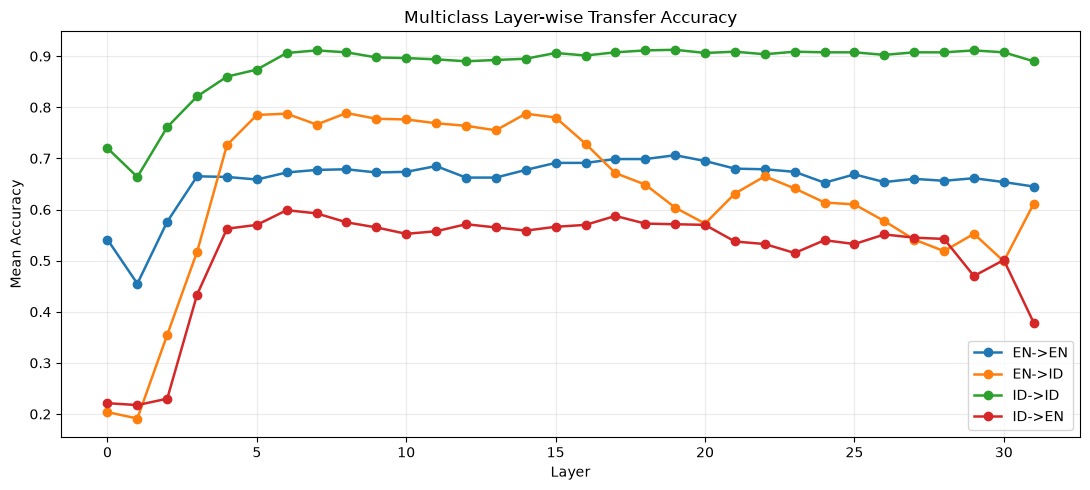

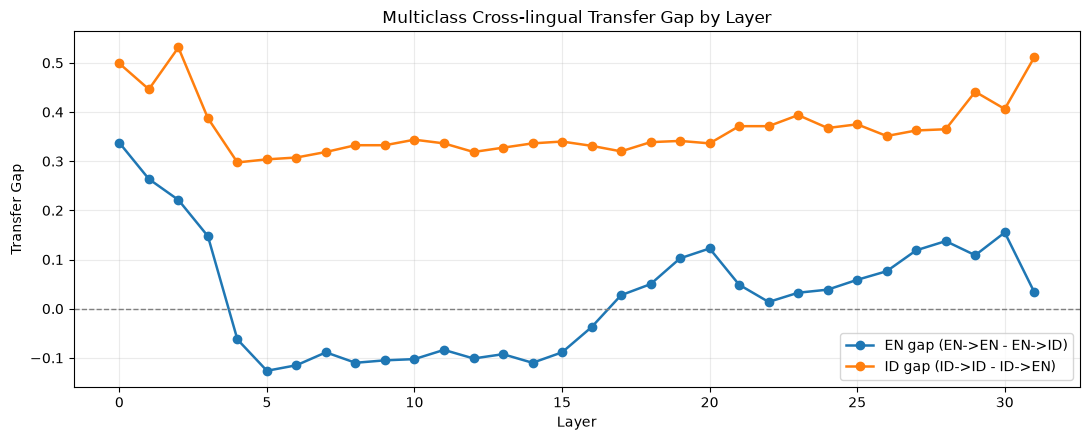

In [31]:
# Print + display multiclass results across all layers
if "multiclass_results_df" not in globals():
    raise ValueError("Run the multiclass training cell first.")

display(multiclass_results_df)

print("\nBest layer per direction:")
for col in ["EN->EN", "EN->ID", "ID->ID", "ID->EN"]:
    best_idx = multiclass_results_df[col].idxmax()
    print(f"{col}: layer {int(multiclass_results_df.loc[best_idx, 'layer'])}, mean acc {multiclass_results_df.loc[best_idx, col]:.4f}")

# Plot similar style to binary section
plt.figure(figsize=(11, 5))
for col in ["EN->EN", "EN->ID", "ID->ID", "ID->EN"]:
    plt.plot(multiclass_results_df["layer"], multiclass_results_df[col], marker="o", linewidth=1.8, label=col)
plt.xlabel("Layer")
plt.ylabel("Mean Accuracy")
plt.title("Multiclass Layer-wise Transfer Accuracy")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

multiclass_results_df["EN_gap"] = multiclass_results_df["EN->EN"] - multiclass_results_df["EN->ID"]
multiclass_results_df["ID_gap"] = multiclass_results_df["ID->ID"] - multiclass_results_df["ID->EN"]

plt.figure(figsize=(11, 4.5))
plt.plot(multiclass_results_df["layer"], multiclass_results_df["EN_gap"], marker="o", linewidth=1.8, label="EN gap (EN->EN - EN->ID)")
plt.plot(multiclass_results_df["layer"], multiclass_results_df["ID_gap"], marker="o", linewidth=1.8, label="ID gap (ID->ID - ID->EN)")
plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Layer")
plt.ylabel("Transfer Gap")
plt.title("Multiclass Cross-lingual Transfer Gap by Layer")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

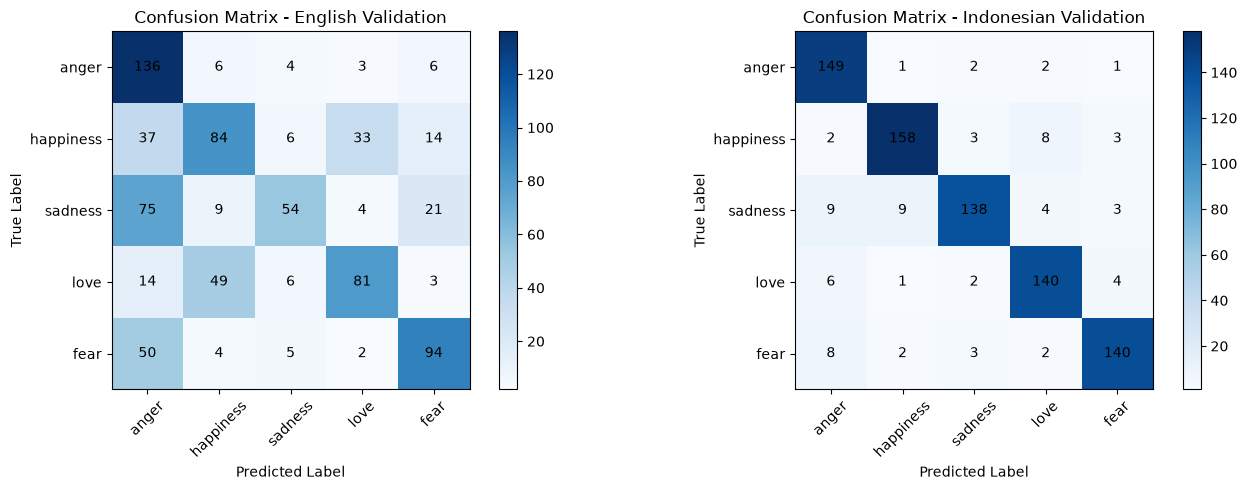

ENGLISH VALIDATION SET
              precision    recall  f1-score   support

       anger       0.44      0.88      0.58       155
   happiness       0.55      0.48      0.52       174
     sadness       0.72      0.33      0.45       163
        love       0.66      0.53      0.59       153
        fear       0.68      0.61      0.64       155

    accuracy                           0.56       800
   macro avg       0.61      0.57      0.56       800
weighted avg       0.61      0.56      0.55       800

INDONESIAN VALIDATION SET
              precision    recall  f1-score   support

       anger       0.86      0.96      0.91       155
   happiness       0.92      0.91      0.92       174
     sadness       0.93      0.85      0.89       163
        love       0.90      0.92      0.91       153
        fear       0.93      0.90      0.92       155

    accuracy                           0.91       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.91     

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import torch

# Collect all predictions and true labels for EN validation set
all_preds_en = []
all_labels_en = []
with torch.no_grad():
    for X_batch, y_batch in emotion_data_eng_val:
        X_batch = X_batch.to(next(probe.parameters()).device)
        outputs = probe(X_batch)
        predicted = torch.argmax(outputs, dim=1)
        all_preds_en.extend(predicted.cpu().numpy())
        all_labels_en.extend(y_batch.numpy())

# Collect all predictions and true labels for ID validation set
all_preds_id = []
all_labels_id = []
with torch.no_grad():
    for X_batch, y_batch in emotion_data_id_val:
        X_batch = X_batch.to(next(probe.parameters()).device)
        outputs = probe(X_batch)
        predicted = torch.argmax(outputs, dim=1)
        all_preds_id.extend(predicted.cpu().numpy())
        all_labels_id.extend(y_batch.numpy())

# Compute confusion matrices
cm_en = confusion_matrix(all_labels_en, all_preds_en, labels=range(len(all_emotions)))
cm_id = confusion_matrix(all_labels_id, all_preds_id, labels=range(len(all_emotions)))

# Visualize side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# English confusion matrix
im_en = axes[0].imshow(cm_en, cmap='Blues')
axes[0].set_xticks(range(len(all_emotions)))
axes[0].set_yticks(range(len(all_emotions)))
axes[0].set_xticklabels(all_emotions, rotation=45)
axes[0].set_yticklabels(all_emotions)
axes[0].set_title('Confusion Matrix - English Validation')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
# Add annotations
for i in range(len(all_emotions)):
    for j in range(len(all_emotions)):
        axes[0].text(j, i, str(cm_en[i, j]), ha='center', va='center', color='black', fontsize=10)
plt.colorbar(im_en, ax=axes[0])

# Indonesian confusion matrix
im_id = axes[1].imshow(cm_id, cmap='Blues')
axes[1].set_xticks(range(len(all_emotions)))
axes[1].set_yticks(range(len(all_emotions)))
axes[1].set_xticklabels(all_emotions, rotation=45)
axes[1].set_yticklabels(all_emotions)
axes[1].set_title('Confusion Matrix - Indonesian Validation')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
# Add annotations
for i in range(len(all_emotions)):
    for j in range(len(all_emotions)):
        axes[1].text(j, i, str(cm_id[i, j]), ha='center', va='center', color='black', fontsize=10)
plt.colorbar(im_id, ax=axes[1])

plt.tight_layout()
plt.show()

# Print classification reports
print("=" * 60)
print("ENGLISH VALIDATION SET")
print("=" * 60)
print(classification_report(all_labels_en, all_preds_en, target_names=all_emotions))

print("=" * 60)
print("INDONESIAN VALIDATION SET")
print("=" * 60)
print(classification_report(all_labels_id, all_preds_id, target_names=all_emotions))

# Mantel Test between different steering vectors

,anger,happiness,sadness,love,fear
anger,1.000000,-0.540271,0.150042,-0.606109,0.178716
happiness,-0.540271,1.000000,-0.464207,0.687524,-0.698205
sadness,0.150042,-0.464207,1.000000,-0.549593,0.381912
love,-0.606109,0.687524,-0.549593,1.000000,-0.726445
fear,0.178716,-0.698205,0.381912,-0.726445,1.000000


,anger,happiness,sadness,love,fear
anger,1.000000,0.542532,-0.471628,-0.804029,0.779932
happiness,0.542532,1.000000,-0.558193,-0.876152,0.733189
sadness,-0.471628,-0.558193,1.000000,0.477763,-0.467894
love,-0.804029,-0.876152,0.477763,1.000000,-0.926039
fear,0.779932,0.733189,-0.467894,-0.926039,1.000000


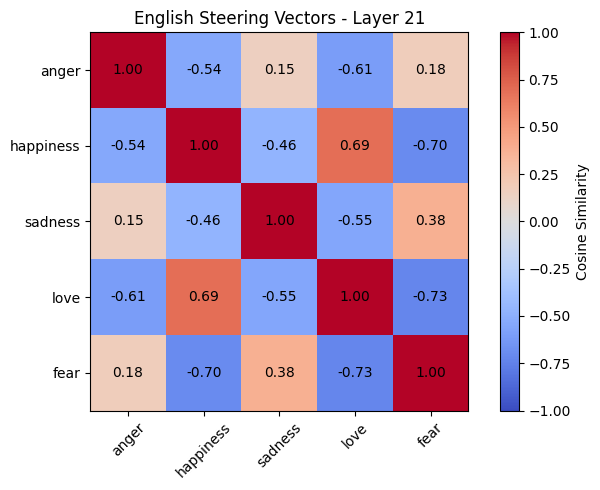

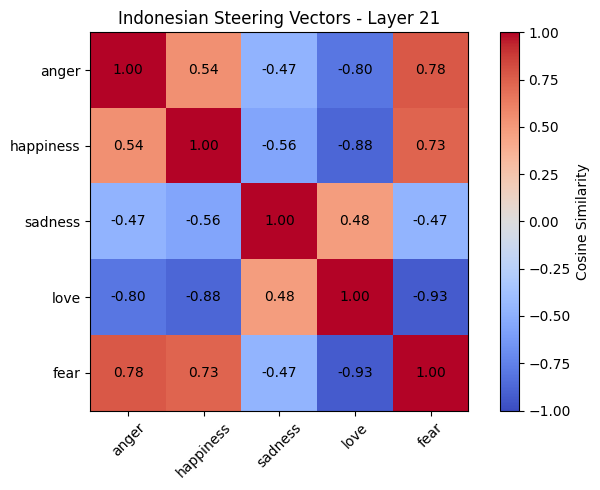

In [4]:


import matplotlib.pyplot as plt

emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']
layer_idx = 21

eng_cosine_matrix = analysis.build_cosine_matrix(steering_vector_eng, emotions, layer_idx)
id_cosine_matrix = analysis.build_cosine_matrix(steering_vector_id, emotions, layer_idx)

display(eng_cosine_matrix)
display(id_cosine_matrix)

plt.figure(figsize=(7, 5))
eng_plot = plt.imshow(eng_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(emotions)), emotions, rotation=45)
plt.yticks(range(len(emotions)), emotions)
plt.title('English Steering Vectors - Layer 21')
analysis.annotate_heatmap(plt.gca(), eng_cosine_matrix.values)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
id_plot = plt.imshow(id_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(emotions)), emotions, rotation=45)
plt.yticks(range(len(emotions)), emotions)
plt.title('Indonesian Steering Vectors - Layer 21')
analysis.annotate_heatmap(plt.gca(), id_cosine_matrix.values)
plt.tight_layout()
plt.show()

In [13]:
mantel_test_result = analysis.mantel_test(eng_cosine_matrix.values, id_cosine_matrix.values, num_permutations=1000)
print(f'Mantel Test Result: {mantel_test_result}')

Mantel Test Result: (np.float64(-0.26093655989224085), 0.453)


# Cosine Similarity across layers 

,emotion,layer,cosine_similarity
0,anger,0,0.262442
1,anger,1,0.986448
2,anger,2,0.968251
3,anger,3,0.919748
4,anger,4,0.855297


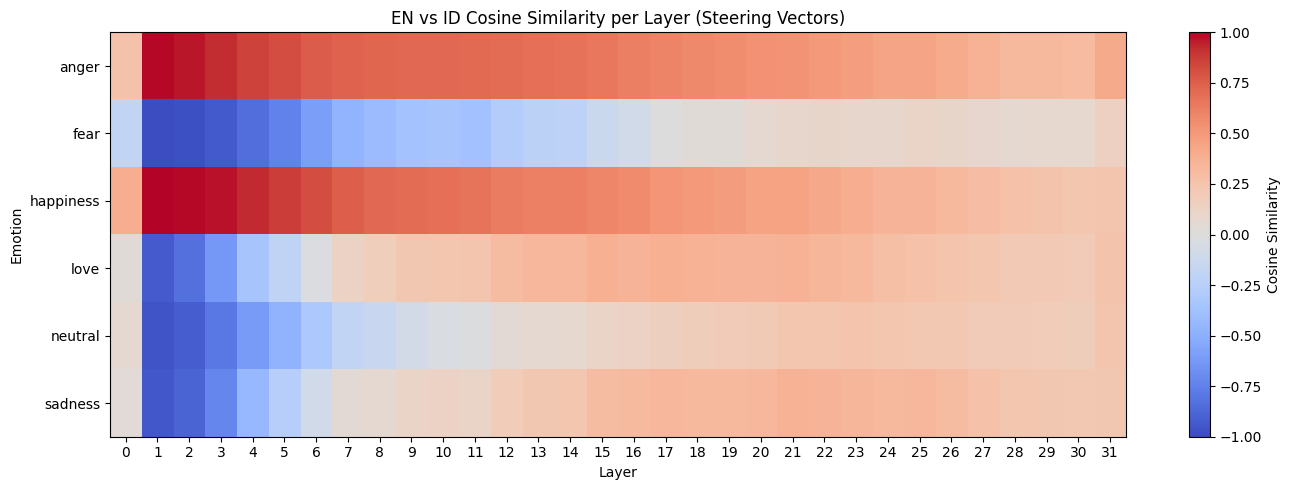

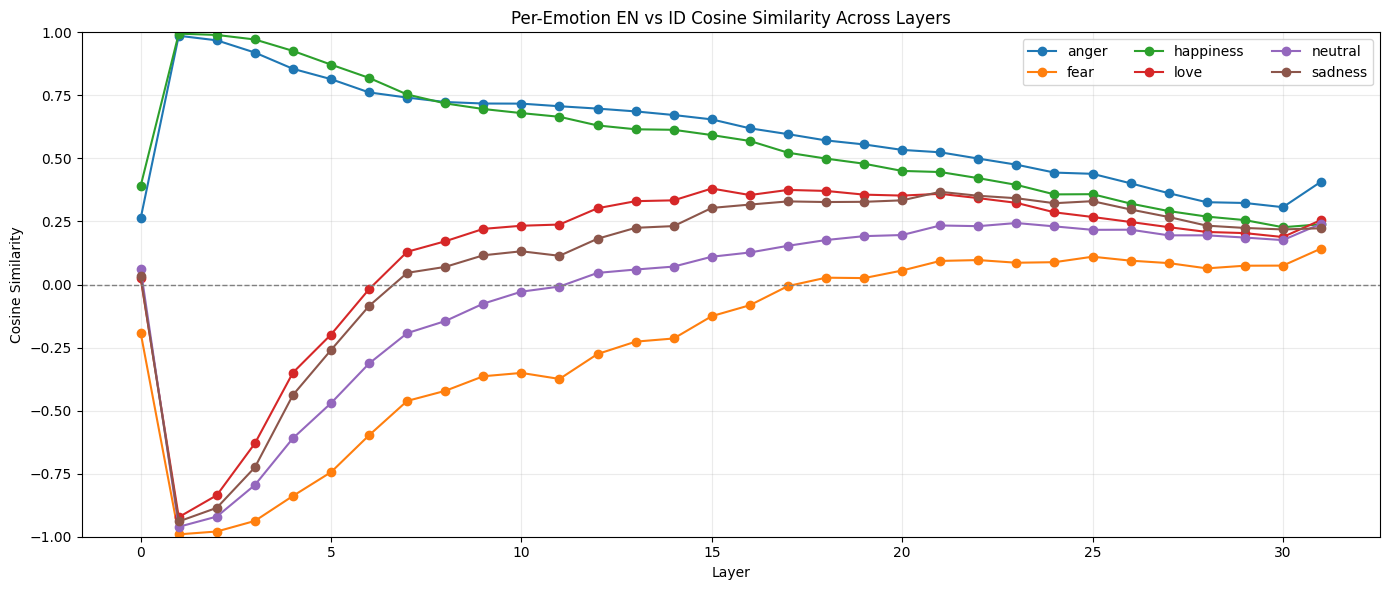

,mean,min,max
emotion,,,
anger,0.602258,0.262442,0.986448
happiness,0.563509,0.227269,0.994790
love,0.129181,-0.922400,0.380684
sadness,0.091719,-0.939441,0.367609
neutral,-0.029900,-0.960747,0.243885
fear,-0.220618,-0.990620,0.142518


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Cosine similarity per layer between EN and ID steering vectors for each emotion
emotions = ["anger", "happiness", "sadness", "love", "fear", "neutral"]
available_emotions = [
    e for e in emotions
    if e in steering_vector_eng and e in steering_vector_id
]

records = []
for emotion in available_emotions:
    en_vec = steering_vector_eng[emotion]
    id_vec = steering_vector_id[emotion]

    if en_vec.shape != id_vec.shape:
        raise ValueError(
            f"Shape mismatch for emotion '{emotion}': EN {en_vec.shape} vs ID {id_vec.shape}"
        )

    layer_sims = F.cosine_similarity(en_vec, id_vec, dim=1)
    for layer_idx, sim in enumerate(layer_sims.tolist()):
        records.append(
            {
                "emotion": emotion,
                "layer": layer_idx,
                "cosine_similarity": sim,
            }
        )

cosine_df = pd.DataFrame(records)
display(cosine_df.head())

# Pivot for heatmap-like matrix: rows = emotions, cols = layers
heatmap_df = cosine_df.pivot(index="emotion", columns="layer", values="cosine_similarity")

plt.figure(figsize=(14, 5))
plt.imshow(heatmap_df.values, aspect="auto", interpolation="nearest", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Cosine Similarity")
plt.yticks(ticks=np.arange(len(heatmap_df.index)), labels=heatmap_df.index)
plt.xticks(ticks=np.arange(len(heatmap_df.columns)), labels=heatmap_df.columns)
plt.xlabel("Layer")
plt.ylabel("Emotion")
plt.title("EN vs ID Cosine Similarity per Layer (Steering Vectors)")
plt.tight_layout()
plt.show()

# Line plot per emotion across layers
plt.figure(figsize=(14, 6))
for emotion in heatmap_df.index:
    plt.plot(heatmap_df.columns, heatmap_df.loc[emotion].values, marker="o", linewidth=1.5, label=emotion)

plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
plt.ylim(-1, 1)
plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Per-Emotion EN vs ID Cosine Similarity Across Layers")
plt.legend(loc="best", ncol=3)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Optional summary table (mean/min/max similarity per emotion)
summary_df = (
    cosine_df.groupby("emotion")["cosine_similarity"]
    .agg(["mean", "min", "max"])
    .sort_values("mean", ascending=False)
)
display(summary_df)

BIDIRECTIONAL TRANSFER: CLEAN COMPARISON

[1] Training probe on ENGLISH data...
Epoch 1/25, Loss: 1.5615
Validation Accuracy: 0.4637
Epoch 2/25, Loss: 1.3951
Validation Accuracy: 0.5950
Epoch 3/25, Loss: 1.2686
Validation Accuracy: 0.5875
Epoch 4/25, Loss: 1.1826
Validation Accuracy: 0.6288
Epoch 5/25, Loss: 1.1018
Validation Accuracy: 0.6312
Epoch 6/25, Loss: 1.0380
Validation Accuracy: 0.6175
Epoch 7/25, Loss: 0.9781
Validation Accuracy: 0.6238
Epoch 8/25, Loss: 0.9282
Validation Accuracy: 0.6362
Epoch 9/25, Loss: 0.8969
Validation Accuracy: 0.6562
Epoch 10/25, Loss: 0.8576
Validation Accuracy: 0.6613
Epoch 11/25, Loss: 0.8244
Validation Accuracy: 0.6713
Epoch 12/25, Loss: 0.7987
Validation Accuracy: 0.6650
Epoch 13/25, Loss: 0.7739
Validation Accuracy: 0.6625
Epoch 14/25, Loss: 0.7531
Validation Accuracy: 0.6750
Epoch 15/25, Loss: 0.7319
Validation Accuracy: 0.6587
Epoch 16/25, Loss: 0.7090
Validation Accuracy: 0.6713
Epoch 17/25, Loss: 0.6916
Validation Accuracy: 0.6725
Epoch 18/25

,Direction,Accuracy
0,EN → EN,0.67625
1,EN → ID,0.69500
2,ID → ID,0.90250
3,ID → EN,0.50500


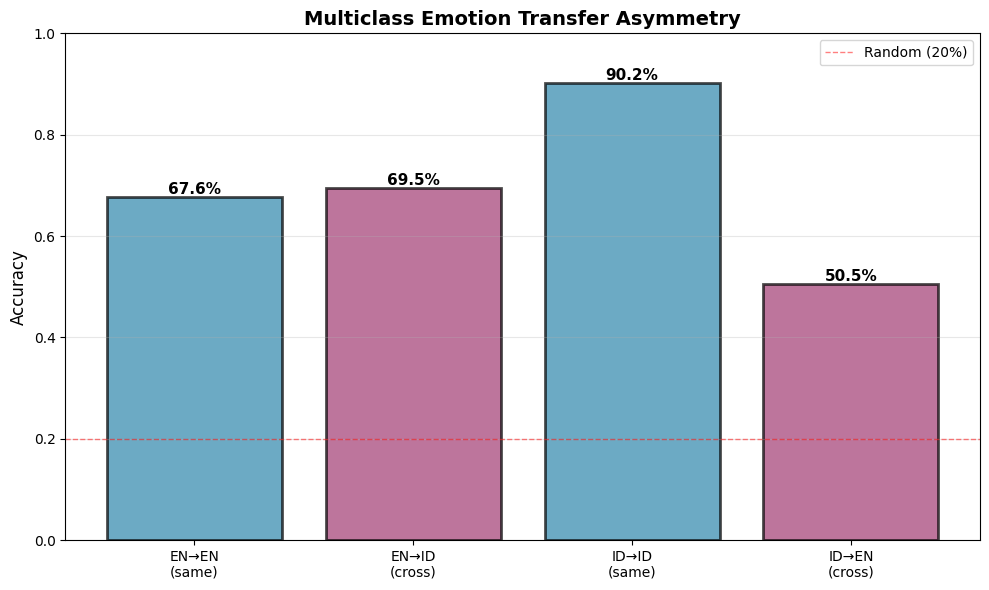

In [21]:
# Clean bidirectional transfer analysis
import matplotlib.pyplot as plt
import numpy as np

print("="*70)
print("BIDIRECTIONAL TRANSFER: CLEAN COMPARISON")
print("="*70)

# Train probe on ENGLISH
print("\n[1] Training probe on ENGLISH data...")
probe_en_fresh = analysis.LogisticRegressionProbe(
    input_dim=emotion_vector_eng[all_emotions[0]][0].shape[-1],
    output_dim=len(all_emotions),
)
probe_en_fresh = analysis.trainMultiClassProbe(
    probe_en_fresh, emotion_data_eng_train, emotion_data_eng_val, num_epochs=25
)

en_self = float(analysis.predictProbe(probe_en_fresh, emotion_data_eng_val, multiclass=True).mean())
en_to_id = float(analysis.predictProbe(probe_en_fresh, emotion_data_id_val, multiclass=True).mean())
print(f"EN trained, tested on EN: {en_self:.4f}")
print(f"EN trained, tested on ID: {en_to_id:.4f}")
print(f"Transfer drop EN→ID: {en_self - en_to_id:.4f}")

# Train probe on INDONESIAN  
print("\n[2] Training probe on INDONESIAN data...")
probe_id_fresh = analysis.LogisticRegressionProbe(
    input_dim=emotion_vector_id[all_emotions[0]][0].shape[-1],
    output_dim=len(all_emotions),
)
probe_id_fresh = analysis.trainMultiClassProbe(
    probe_id_fresh, emotion_data_id_train, emotion_data_id_val, num_epochs=25
)

id_self = float(analysis.predictProbe(probe_id_fresh, emotion_data_id_val, multiclass=True).mean())
id_to_en = float(analysis.predictProbe(probe_id_fresh, emotion_data_eng_val, multiclass=True).mean())
print(f"ID trained, tested on ID: {id_self:.4f}")
print(f"ID trained, tested on EN: {id_to_en:.4f}")
print(f"Transfer drop ID→EN: {id_self - id_to_en:.4f}")

# Summary comparison
print("\n" + "="*70)
print("TRANSFER SUMMARY")
print("="*70)
transfer_summary = pd.DataFrame({
    'Direction': ['EN → EN', 'EN → ID', 'ID → ID', 'ID → EN'],
    'Accuracy': [en_self, en_to_id, id_self, id_to_en],
})
display(transfer_summary)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
directions = ['EN→EN\n(same)', 'EN→ID\n(cross)', 'ID→ID\n(same)', 'ID→EN\n(cross)']
accuracies = [en_self, en_to_id, id_self, id_to_en]
colors = ['#2E86AB', '#A23B72', '#2E86AB', '#A23B72']

bars = ax.bar(directions, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Multiclass Emotion Transfer Asymmetry', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.0])
ax.axhline(0.2, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Random (20%)')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.legend()
plt.tight_layout()
plt.show()